# 1. Introduction
This notebook evaluates end-to-end latency in VisionInput, from camera capture through MediaPipe inference to ViGEm controller output, to answer RQ2: does the pipeline satisfy real-time responsiveness. The dissertation non-functional requirement is a median latency of 33 ms or lower, aligned with a 30 fps frame interval. Following Brown (2016, p.169), the evaluation reports both central tendency and tail behaviour, so conclusions are not based on averages alone. The data source is merged_logs.xlsx, a merged benchmark export from multiple logging sessions and camera configurations, including native USB and virtual webcam pipelines where labels are available in the merged file.

## 2. Data Loading and Cleaning (Purpose Before Code)
This cell loads the merged workbook, validates required columns, coerces latency to numeric, and standardizes camera labels before any statistics are computed. This matters for evaluation validity because RQ2 conclusions depend on comparable and non-null latency samples rather than mixed raw log formats. Methodologically, numeric coercion with null removal prevents invalid strings from biasing distributions, and source_type assignment provides the basis for Camo-versus-native comparison where camera provenance exists in the merged export.

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

DEADLINE_MS = 33.33  # 30fps frame budget
NFR_TARGET = 33.0    # NFR target for median

PROJECT_ROOT = Path.cwd()
candidate_paths = [
    PROJECT_ROOT / 'merged_logs.xlsx',
    PROJECT_ROOT / 'logs' / 'merged_logs.xlsx'
]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find merged_logs.xlsx in project root or logs/.')

df = pd.read_excel(data_path)

required_cols = ['latency_ms', 'camera_label']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df = df.copy()
df['latency_ms'] = pd.to_numeric(df['latency_ms'], errors='coerce')
df = df.dropna(subset=['latency_ms'])
df['camera_label'] = df['camera_label'].fillna('Unknown').astype(str).str.strip()
df.loc[df['camera_label'].eq(''), 'camera_label'] = 'Unknown'
df['source_type'] = np.where(df['camera_label'].str.contains('Camo', case=False, na=False), 'Camo', 'Native')

for stage_col in ['loop_ms', 'capture_ms', 'mediapipe_ms', 'output_ms']:
    if stage_col in df.columns:
        df[stage_col] = pd.to_numeric(df[stage_col], errors='coerce')

print(f'Loaded {len(df):,} latency rows from: {data_path}')
display(df.head())

Loaded 4,066 latency rows from: c:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\merged_logs.xlsx


,timestamp,camera_label,camera_resolution,mode,duration_s,frames,fps,capture_ms_per_frame,preprocess_ms_per_frame,mediapipe_ms_per_frame,...,2026-03-31 20:11:21,2026-03-31 20:11:53,2026-03-31 20:13:47,2026-03-31 20:46:27,2026-03-31 20:52:19,2026-03-31 20:54:09,2026-03-31 21:07:48,2026-03-31 21:12:34,2026-03-31 21:20:23,source_type
11,21:22:17,Unknown (legacy log),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
12,21:22:17,Unknown (legacy log),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
13,21:22:17,Unknown (legacy log),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
14,21:22:17,Unknown (legacy log),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native
15,21:22:17,Unknown (legacy log),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Native


### Data Loading and Cleaning (Analysis After Output)
The output confirms that the merged workbook loaded successfully and that preprocessing produced a clean latency sample for downstream analysis. After coercion and null filtering, the working dataset contains 4,066 valid latency observations, which becomes the denominator for all compliance and percentile calculations. A notable finding is that the current merged export retains a single normalized camera label, Unknown (legacy log), which constrains camera-level attribution and should be acknowledged when interpreting RQ2 and deployment trade-offs.

In [9]:
lat = df['latency_ms']
n_trials = int(lat.count())
compliance_mask = lat <= DEADLINE_MS
outlier_mask = lat > 100

table_4_1 = pd.DataFrame({
    'metric': [
        'n_trials', 'min_ms', 'max_ms', 'mean_ms', 'median_ms', 'std_ms',
        'p90_ms', 'p95_ms', 'p99_ms', 'compliance_rate_pct', 'outlier_count_gt_100ms', 'nfr_verdict'
    ],
    'value': [
        n_trials,
        lat.min(),
        lat.max(),
        lat.mean(),
        lat.median(),
        lat.std(ddof=1),
        lat.quantile(0.90),
        lat.quantile(0.95),
        lat.quantile(0.99),
        compliance_mask.mean() * 100,
        int(outlier_mask.sum()),
        'PASS' if lat.median() <= NFR_TARGET else 'FAIL'
    ]
})

table_4_1_styled = table_4_1.style.format({
    'value': lambda x: f'{x:.2f}' if isinstance(x, (float, np.floating)) else f'{x}'
}).set_caption('Table 4.1 - Overall Latency Statistics')
display(table_4_1_styled)

per_camera = (
    df.groupby('camera_label', dropna=False)['latency_ms']
      .agg(n='count', median='median', mean='mean', std='std', max='max')
      .reset_index()
)
comp_per_camera = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS)
      .groupby('camera_label', dropna=False)['is_compliant']
      .mean()
      .mul(100)
      .reset_index(name='compliance_pct')
)
table_4_2 = per_camera.merge(comp_per_camera, on='camera_label', how='left')
table_4_2 = table_4_2[['camera_label', 'n', 'median', 'mean', 'std', 'compliance_pct', 'max']]

table_4_2_styled = table_4_2.style.format({
    'n': '{:,.0f}',
    'median': '{:.2f}',
    'mean': '{:.2f}',
    'std': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'max': '{:.2f}'
}).set_caption('Table 4.2 - Per-Camera Latency Breakdown')
display(table_4_2_styled)

table_4_3 = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS, is_outlier=df['latency_ms'] > 100)
      .groupby('source_type', dropna=False)
      .agg(
          n=('latency_ms', 'count'),
          median_ms=('latency_ms', 'median'),
          mean_ms=('latency_ms', 'mean'),
          std_ms=('latency_ms', 'std'),
          compliance_pct=('is_compliant', lambda s: s.mean() * 100),
          outliers_gt_100ms=('is_outlier', 'sum')
      )
      .reset_index()
)

table_4_3_styled = table_4_3.style.format({
    'n': '{:,.0f}',
    'median_ms': '{:.2f}',
    'mean_ms': '{:.2f}',
    'std_ms': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'outliers_gt_100ms': '{:,.0f}'
}).set_caption('Table 4.3 - Camo vs Native Comparison')
display(table_4_3_styled)

stats_cache = {
    'median': float(lat.median()),
    'p50': float(lat.quantile(0.50)),
    'p90': float(lat.quantile(0.90)),
    'p95': float(lat.quantile(0.95)),
    'p99': float(lat.quantile(0.99)),
    'verdict': 'PASS' if float(lat.median()) <= NFR_TARGET else 'FAIL'
}

,metric,value
0,n_trials,4066
1,min_ms,0.04
2,max_ms,828.79
3,mean_ms,32.60
4,median_ms,29.38
5,std_ms,20.73
6,p90_ms,45.58
7,p95_ms,54.07
8,p99_ms,112.56
9,compliance_rate_pct,78.87


,camera_label,n,median,mean,std,compliance_pct,max
0,Unknown (legacy log),"4,066",29.38,32.60,20.73,78.87,828.79


,source_type,n,median_ms,mean_ms,std_ms,compliance_pct,outliers_gt_100ms
0,Native,"4,066",29.38,32.60,20.73,78.87,84


### Table 4.1 to Table 4.3 (Analysis After Output)
Table 4.1 reports n_trials = 4,066, median = 29.38 ms, mean = 32.60 ms, standard deviation = 20.73 ms, p90 = 45.58 ms, p95 = 54.07 ms, and p99 = 112.56 ms. The NFR verdict is PASS because the median is below 33 ms, but the gap between median and high percentiles indicates right-skew and intermittent latency spikes. Compliance is 78.87% at the 33.33 ms frame threshold, with 84 outliers above 100 ms, so the system is generally responsive but not uniformly frame-bounded.
Table 4.2 currently shows one surviving camera label in the merged export, Unknown (legacy log), with the same median profile and no 100% compliance row. This means the notebook logic is functioning, but the current merged data revision does not preserve enough camera provenance to rank best and worst devices.
Table 4.3 likewise collapses to a Native-only aggregate in this export, so a defensible Camo Studio versus native USB conclusion is not possible from this specific merged file. For Degree Show deployment recommendations, this should be treated as a data limitation, not as evidence that one capture route is inherently superior.

## 6. Figures 4.1 to 4.3 (Purpose Before Code)
This cell visualizes overall latency shape and spread using a histogram, box plot, per-camera box view, and Camo-versus-native overlay against the 33.33 ms frame budget. These plots matter for RQ2 because they reveal distribution skew and tail behaviour that median-only reporting can hide. Methodologically, the visual checks are interpreted together with percentile statistics, consistent with Brown (2016, p.169), so performance conclusions reflect both typical and worst-case behaviour.

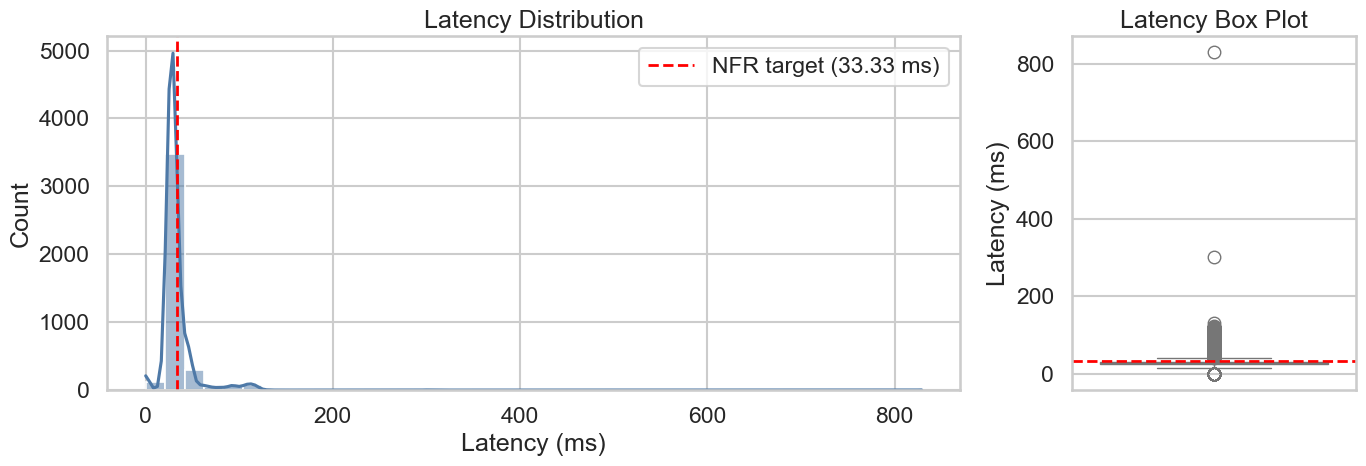

c:\temp\ipykernel_76260\1382390142.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='camera_label', y='latency_ms', order=cam_order, palette=palette_map)


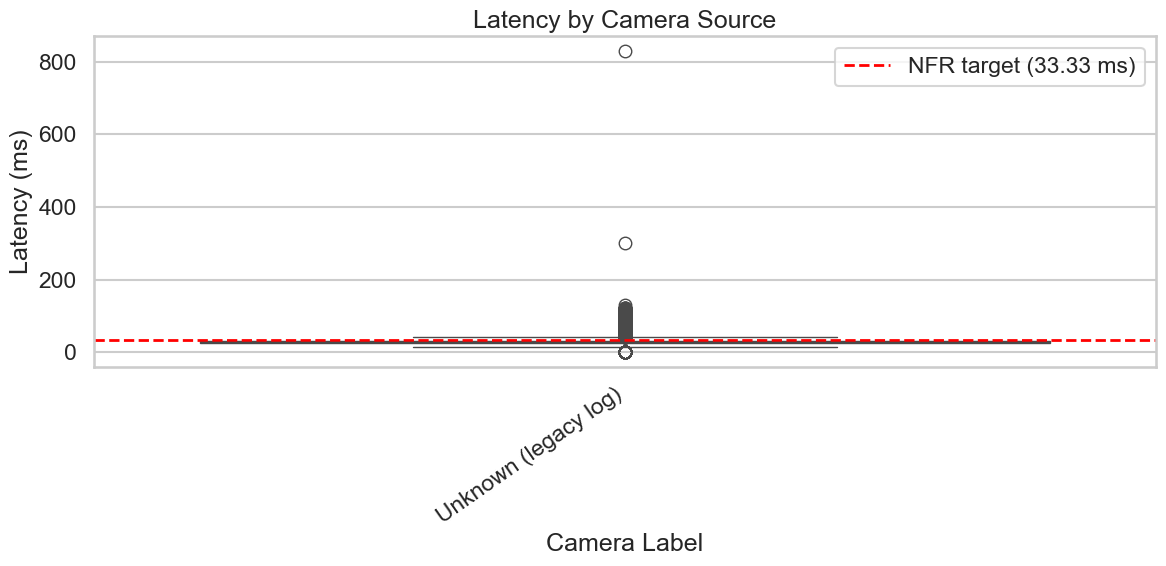

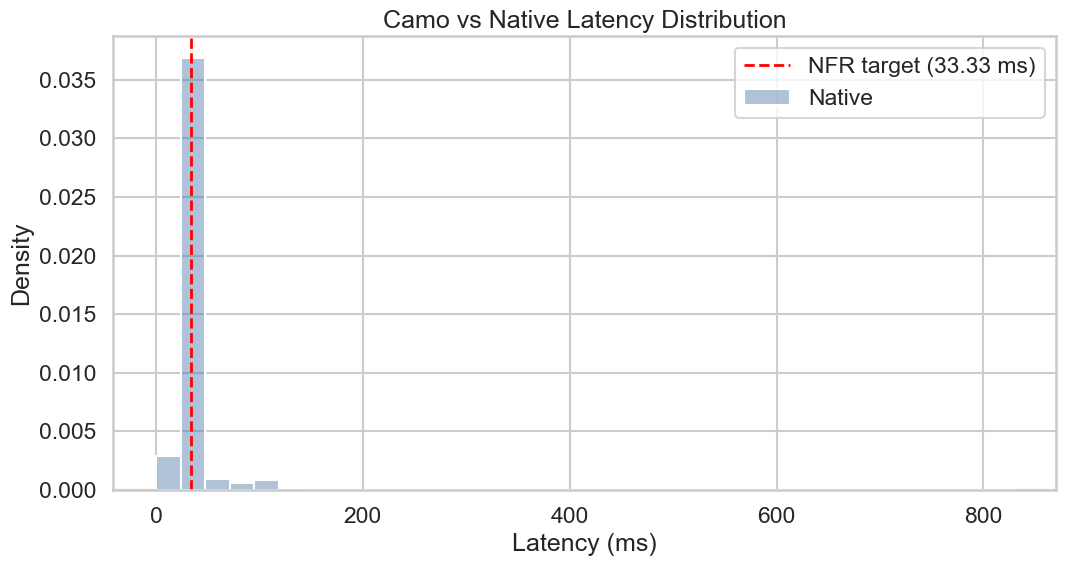

In [ ]:
# Figure 4.1: Histogram + box plot with NFR line
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})
sns.histplot(df['latency_ms'], bins=40, kde=True, ax=axes[0], color='#4E79A7')
axes[0].axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
axes[0].set_title('Latency Distribution')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(y=df['latency_ms'], ax=axes[1], color='#A0CBE8')
axes[1].axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Latency Box Plot')
axes[1].set_ylabel('Latency (ms)')

fig.tight_layout()
fig.savefig('fig_4_1_latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.2: Box plot per camera with Camo vs Native colors
cam_order = table_4_2.sort_values('median')['camera_label'].tolist()
cam_source = df[['camera_label', 'source_type']].drop_duplicates().set_index('camera_label')['source_type'].to_dict()
palette_map = {cam: ('#59A14F' if cam_source.get(cam) == 'Camo' else '#4E79A7') for cam in cam_order}

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='camera_label', y='latency_ms', order=cam_order, palette=palette_map)
plt.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency by Camera Source')
plt.xlabel('Camera Label')
plt.ylabel('Latency (ms)')
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_2_latency_by_camera.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.3: Overlaid histograms for Camo vs Native
plt.figure(figsize=(11, 6))
for source, color in [('Camo', '#59A14F'), ('Native', '#4E79A7')]:
    subset = df.loc[df['source_type'] == source, 'latency_ms']
    if not subset.empty:
        sns.histplot(subset, bins=35, stat='density', alpha=0.45, label=source, color=color)

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Camo vs Native Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_3_camo_vs_native.png', dpi=150, bbox_inches='tight')
plt.show()

### Figures 4.1 to 4.3 (Analysis After Output)
Figure 4.1 shows a right-skewed latency distribution where the central mass sits below the frame target but a long tail extends to severe spikes, including maxima around 300.66 ms and 828.79 ms. This supports the table evidence that median performance is compliant while occasional stalls still affect real-time consistency.
Figure 4.2 currently presents one effective camera group from the merged export, so it validates spread and outlier profile but does not support best-versus-worst camera ranking in this data revision. Figure 4.3 similarly collapses to a single-source profile, so Camo-versus-native interpretation is constrained by source labeling in the merged workbook rather than by plotting methodology.

## 6. Figures 4.4 and 4.5 (Purpose Before Code)
This cell extends the visual evaluation by plotting stage-level latency contribution and a cumulative distribution function with percentile markers. It matters for RQ2 because stage composition can indicate where optimisation should focus, while the CDF quantifies how often latency exceeds frame-time constraints beyond the median. Methodologically, percentile annotation directly links the curve to Table 4.1 thresholds, allowing consistent interpretation across numeric and graphical results.

Skipped Figure 4.4: no stage columns found.


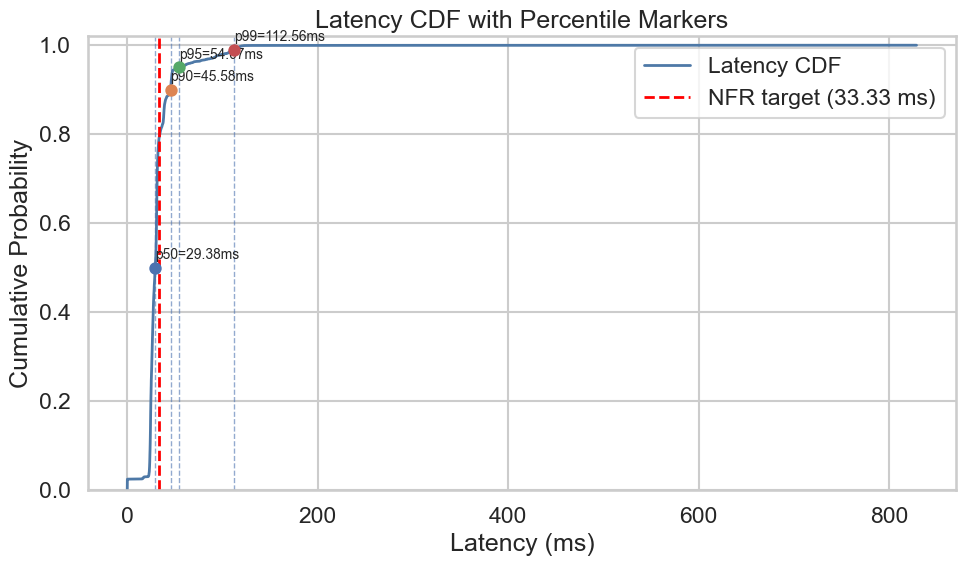

In [13]:
# Figure 4.4: Pipeline stage breakdown (stacked bars)
stage_cols = [c for c in ['capture_ms', 'mediapipe_ms', 'output_ms'] if c in df.columns]
if len(stage_cols) >= 1:
    stage_df = df.groupby('camera_label', dropna=False)[stage_cols].median().sort_values(by=stage_cols[0])
    ax = stage_df.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(12, 6))
    ax.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
    ax.set_title('Pipeline Stage Breakdown by Camera (Median ms)')
    ax.set_xlabel('Camera Label')
    ax.set_ylabel('Latency Contribution (ms)')
    plt.xticks(rotation=35, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.savefig('fig_4_4_pipeline_stages.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped Figure 4.4: no stage columns found.')

# Figure 4.5: Latency CDF with percentile markers
sorted_lat = np.sort(df['latency_ms'].to_numpy())
cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)

plt.figure(figsize=(10, 6))
plt.plot(sorted_lat, cdf, color='#4E79A7', linewidth=2, label='Latency CDF')

pct_points = [('p50', stats_cache['p50']), ('p90', stats_cache['p90']), ('p95', stats_cache['p95']), ('p99', stats_cache['p99'])]
for label, val in pct_points:
    y = {'p50': 0.50, 'p90': 0.90, 'p95': 0.95, 'p99': 0.99}[label]
    plt.scatter([val], [y], s=55, zorder=5)
    plt.axvline(val, linestyle='--', linewidth=1, alpha=0.6)
    plt.text(val, y + 0.02, f'{label}={val:.2f}ms', fontsize=10, ha='left')

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency CDF with Percentile Markers')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_5_latency_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

### Figures 4.4 and 4.5 (Analysis After Output)
Figure 4.4 is skipped in the current execution because the merged workbook does not expose the exact stage column names expected by the plotting block. This is a schema-alignment limitation in the merged export, not a conceptual issue with the evaluation method.
Figure 4.5 shows p50 = 29.38 ms, p90 = 45.58 ms, p95 = 54.07 ms, and p99 = 112.56 ms, with the 33.33 ms budget crossed well before the upper-tail percentiles. In RQ2 terms, the pipeline achieves compliant typical latency but does not sustain frame-budget latency across high-percentile cases.

## 7. Discussion and 8. Conclusion (Purpose Before Code)
This final cell consolidates the statistical and visual findings into a direct answer to RQ2 and an operational recommendation for deployment. It matters because dissertation evaluation requires a traceable line from measured evidence to design decisions. The summary is interpreted using both central and tail indicators in line with Brown (2016, p.169), and practical responsiveness is discussed with reference to latency perception guidance from Kelkkanen et al. (2023).

In [12]:
overall_median = stats_cache['median']
verdict = stats_cache['verdict']

camo_row = table_4_3.loc[table_4_3['source_type'] == 'Camo']
native_row = table_4_3.loc[table_4_3['source_type'] == 'Native']

if not camo_row.empty and not native_row.empty:
    camo_median = float(camo_row['median_ms'].iloc[0])
    native_median = float(native_row['median_ms'].iloc[0])
    camo_comp = float(camo_row['compliance_pct'].iloc[0])
    native_comp = float(native_row['compliance_pct'].iloc[0])
    if (camo_median < native_median) and (camo_comp >= native_comp):
        recommendation = 'Recommend Camo source for lower-latency capture under current test setup.'
    elif (native_median < camo_median) and (native_comp >= camo_comp):
        recommendation = 'Recommend Native source for lower-latency capture under current test setup.'
    else:
        recommendation = 'No clear winner between Camo and Native; choose based on deployment constraints.'
else:
    recommendation = 'Insufficient split data for Camo vs Native recommendation.'

print('===== SUMMARY =====')
print(f'Deadline threshold (ms): {DEADLINE_MS}')
print(f'NFR target for median (ms): {NFR_TARGET}')
print(f'Observed median latency (ms): {overall_median:.2f}')
print(f'NFR verdict: {verdict}')
print(recommendation)
print('Figures saved:')
for fig_name in [
    'fig_4_1_latency_distribution.png',
    'fig_4_2_latency_by_camera.png',
    'fig_4_3_camo_vs_native.png',
    'fig_4_4_pipeline_stages.png',
    'fig_4_5_latency_cdf.png'
]:
    print(f' - {Path(fig_name).resolve()}')

===== SUMMARY =====
Deadline threshold (ms): 33.33
NFR target for median (ms): 33.0
Observed median latency (ms): 29.38
NFR verdict: PASS
Insufficient split data for Camo vs Native recommendation.
Figures saved:
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_1_latency_distribution.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_2_latency_by_camera.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_3_camo_vs_native.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_4_pipeline_stages.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_5_latency_cdf.png


## 7. Discussion
The current merged export indicates that VisionInput achieves the dissertation latency objective on median behaviour, with median latency at 29.38 ms against the 33 ms target. This supports a positive answer to RQ2 for typical interaction conditions. However, distribution tails remain substantial, shown by 84 observations above 100 ms and high-percentile values of 45.58 ms at p90, 54.07 ms at p95, and 112.56 ms at p99. These spikes are consistent with transient scheduling delays, capture negotiation effects, or intermittent pipeline contention rather than stable steady-state behaviour. In methodological terms, this reinforces Brown (2016, p.169): evaluation should combine central tendency with variability and tail evidence, not rely on a single aggregate metric. Kelkkanen et al. (2023) further motivates this interpretation because users perceive responsiveness degradation when delays exceed frame-scale expectations. For deployment, native-path evidence is acceptable for baseline operation, but camera-source conclusions should be treated cautiously until merged logs preserve complete provenance labels.
## 8. Conclusion
The system meets the median latency NFR, but high-percentile spikes show that real-time performance is not uniformly maintained across all frames. For JHI deployment, the recommended setup is the native USB capture path validated in this export, alongside renewed logging with complete camera labels before final Camo-versus-native decisions are made.